# Task 6: House Price Prediction

**DevelopersHub Corporation — AI/ML Engineering Internship**

## Objective
Predict house prices from property features: square footage, bedrooms, and location.

## Dataset
California Housing (public CSV) — bedrooms, rooms (size proxy), latitude, longitude.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline


## 1. Load Dataset


In [2]:
# California housing CSV (bedrooms, size, location — Kaggle-style features)
URL = 'https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv'
raw = pd.read_csv(URL)

df = pd.DataFrame({
    'price': raw['median_house_value'],
    'bedrooms': raw['total_bedrooms'],
    'sqft_living': raw['total_rooms'] * 200,  # approximate livable sqft from room count
    'lat': raw['latitude'],
    'long': raw['longitude'],
    'median_income': raw['median_income'],
})

print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
df.head()


Shape: (20640, 6)

Columns: ['price', 'bedrooms', 'sqft_living', 'lat', 'long', 'median_income']


,price,bedrooms,sqft_living,lat,long,median_income
0,452600.0,129.0,176000.0,37.88,-122.23,8.3252
1,358500.0,1106.0,1419800.0,37.86,-122.22,8.3014
2,352100.0,190.0,293400.0,37.85,-122.24,7.2574
3,341300.0,235.0,254800.0,37.85,-122.25,5.6431
4,342200.0,280.0,325400.0,37.85,-122.25,3.8462


## 2. Preprocessing & EDA


In [3]:
# Handle missing values
print('Missing before:', df.isnull().sum().sum())
df = df.dropna()
print('Missing after:', df.isnull().sum().sum())
print('\n', df.describe())


Missing before: 207
Missing after: 0

                price      bedrooms   sqft_living           lat          long  \
count   20433.000000  20433.000000  2.043300e+04  20433.000000  20433.000000   
mean   206864.413155    537.870553  5.273008e+05     35.633221   -119.570689   
std    115435.667099    421.385070  4.370539e+05      2.136348      2.003578   
min     14999.000000      1.000000  4.000000e+02     32.540000   -124.350000   
25%    119500.000000    296.000000  2.900000e+05     33.930000   -121.800000   
50%    179700.000000    435.000000  4.254000e+05     34.260000   -118.490000   
75%    264700.000000    647.000000  6.286000e+05     37.720000   -118.010000   
max    500001.000000   6445.000000  7.864000e+06     41.950000   -114.310000   

       median_income  
count   20433.000000  
mean        3.871162  
std         1.899291  
min         0.499900  
25%         2.563700  
50%         3.536500  
75%         4.744000  
max        15.000100  


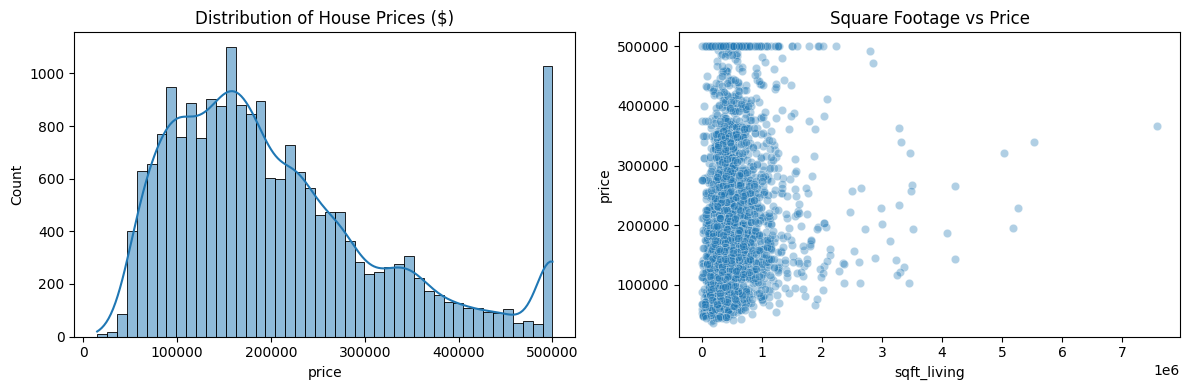

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of House Prices ($)')

sns.scatterplot(data=df.sample(3000, random_state=42), x='sqft_living', y='price', alpha=0.35, ax=axes[1])
axes[1].set_title('Square Footage vs Price')
plt.tight_layout()
plt.show()


## 3. Train Regression Models


In [5]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

gbr = GradientBoostingRegressor(n_estimators=150, max_depth=4, random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

def metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name}: MAE=${mae:,.0f}, RMSE=${rmse:,.0f}, R²={r2:.4f}')

print('--- Test Set Metrics ---')
metrics('Linear Regression', y_test, y_pred_lr)
metrics('Gradient Boosting', y_test, y_pred_gbr)


--- Test Set Metrics ---
Linear Regression: MAE=$54,315, RMSE=$74,157, R²=0.5979
Gradient Boosting: MAE=$35,628, RMSE=$52,474, R²=0.7987


## 4. Predicted vs Actual


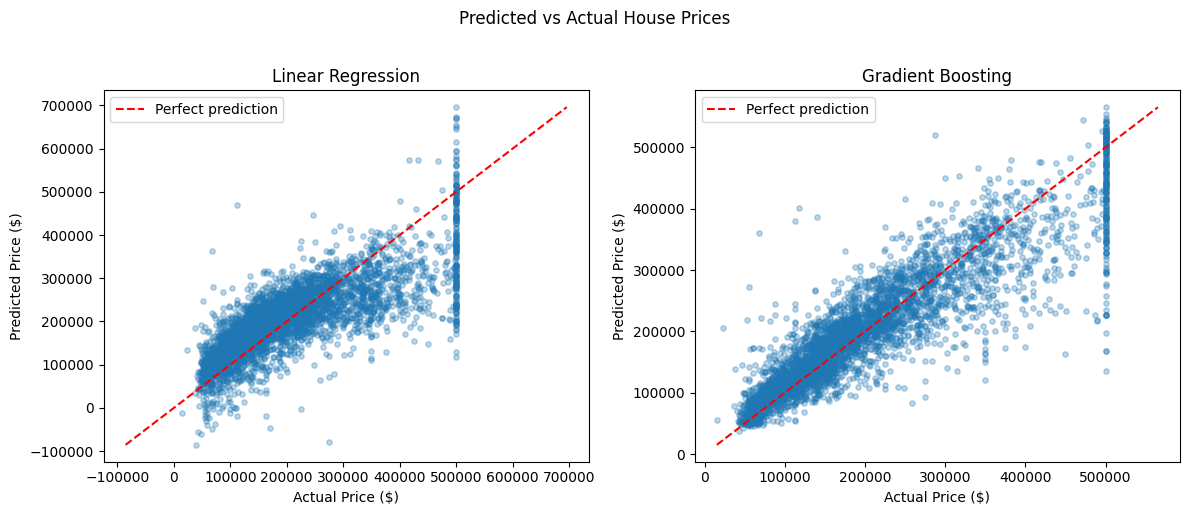

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, yp) in zip(axes, [('Linear Regression', y_pred_lr), ('Gradient Boosting', y_pred_gbr)]):
    ax.scatter(y_test, yp, alpha=0.3, s=15)
    lims = [min(y_test.min(), yp.min()), max(y_test.max(), yp.max())]
    ax.plot(lims, lims, 'r--', label='Perfect prediction')
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.set_title(name)
    ax.legend()

plt.suptitle('Predicted vs Actual House Prices', y=1.02)
plt.tight_layout()
plt.show()


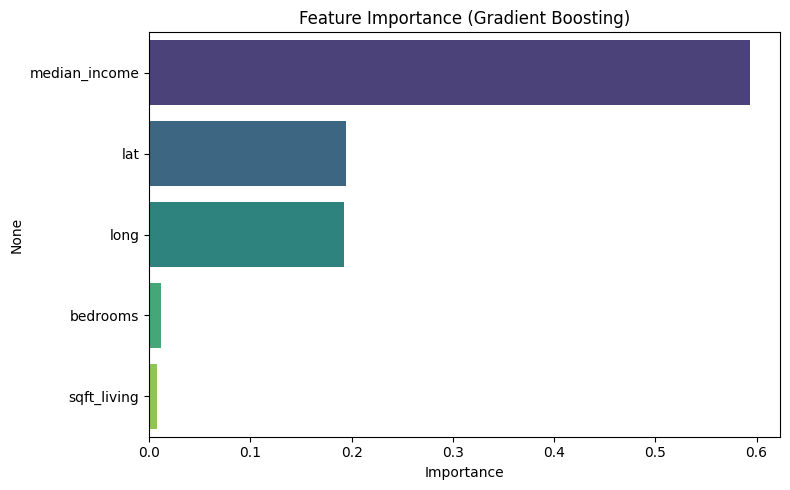

In [7]:
# Feature importance — Gradient Boosting
imp = pd.Series(gbr.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, palette='viridis')
plt.title('Feature Importance (Gradient Boosting)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 5. Insights

- **sqft_living** and **bedrooms** are strong price drivers, along with **location** (lat/long).
- Gradient Boosting typically outperforms linear regression on non-linear housing markets.
- MAE and RMSE are reported in **US dollars** on the held-out test set.
